In [1]:
from reasonable_crowd.parse_map import parse_map
from reasonable_crowd.dataset import build_evaluation_dataset, get_trajectories, load_annotations
import os
from rulebook_benchmark.realization import VariableHandler
from rulebook_benchmark.rule_functions import RuleEngine
import networkx as nx
from rulebook_benchmark.rule_functions import (
    f1, f2, f3, f4, f5, f6, f7, f8, f9, f11, f12, f13, f15, f17, f18, Result
)
from rulebook_benchmark.rulebook import Rulebook
from reasonable_crowd.InPlaceRulebook import InPlaceRulebook
import numpy as np
import pandas as pd
from reasonable_crowd.optimization import cache_rule_evaluations, optimize_rulebook_grid_bruteforce_with_validation, simulated_annealing, simulated_annealing_with_validation, number_of_unique_rulebooks, find_scenario_rulebooks, shuffle_rulebook
import pickle
from sklearn.model_selection import train_test_split
from reasonable_crowd.evaluation import evaluate_rulebook_with_cache
from sklearn.model_selection import KFold
from reasonable_crowd.visualization import plot_topological_graph, plot_two_rulebooks_side_by_side
from rulebook_benchmark.plotting import compare_realizations_gif

path_to_reasonable_crowd = "../../../Reasonable-Crowd"
map_directory = path_to_reasonable_crowd + '/maps'
trajectory_directory = path_to_reasonable_crowd + '/trajectories'
rule_id_to_name = {1: "vru_collision", 2: "vehicle_collision", 3: "drivable_area", 4: "vru_ttc", 5: "vru_acknowledgement", 6: "vehicle_ttc", 7:"correct_side", 8: "vru_offroad", 9: "vru_onroad", 11: "front_clearance", 12: "left_clearance", 13: "right_clearance", 15: "speed_limit", 17: "lane_keeping", 18: "lane_centering"}
network_U = parse_map(map_directory, 'U')
network_S = parse_map(map_directory, 'S')

output_directory = 'outputs'
output_file = os.path.join(output_directory, 'results_scenic.txt')

trajectories = get_trajectories(output_directory, trajectory_directory, network_U, network_S)

trajectories_dict = {}
for filename, realization in trajectories:
    trajectories_dict[filename[:-5]] = realization  # remove .json extension

data = load_annotations(path_to_reasonable_crowd)

X, y, y_votes = build_evaluation_dataset(data)
# create pandas dataframe
df = pd.DataFrame(columns=['X', 'y', 'votes'])
df['X'] = X
df['y'] = y
df['votes'] = y_votes

print(df.head())

rb = Rulebook(rule_file="reasonable_crowd_rule_functions.py", rulebook_file="reasonable_crowd_4.graph")
rule_id_to_rule = {1: f1, 2: f2, 3: f3, 4: f4, 5: f5, 6: f6, 7: f7, 8: f8, 9: f9, 11: f11, 12: f12, 13: f13, 15: f15, 17: f17, 18: f18}
rulebook = InPlaceRulebook(rb.priority_graph, rule_id_to_rule)

rule_id_to_params = {4: ["threshold"], 6: ["threshold"], 8: ["threshold"], 9: ["threshold"], 5: ["velocity", "threshold", "timesteps"], 11: ["threshold"], 12: ["threshold"], 13: ["threshold"], 18: ["buffer"]}
rule_id_to_values = {4: {"threshold": [0.3, 0.5, 0.8, 1]}, 6: {"threshold": [0.3, 0.5, 0.8, 1]}, 8: {"threshold": [0.5, 1, 1.5, 2]}, 9: {"threshold": [0.5 , 1, 1.5, 2]}, 5: {"velocity": [4], "threshold": [-1, -0.5, -0.2, 0], "timesteps": [30]}, 11: {"threshold": [0.5, 0.8, 1, 1.5]}, 12: {"threshold": [0.5, 0.8, 1, 1.5]}, 13: {"threshold": [0.5, 0.8, 1, 1.5]}, 18: {"buffer": [0.3, 0.5, 0.8]}}

if os.path.exists(os.path.join(output_directory, 'tuning_cache.pkl')):
    print("Loading cached rule evaluations...")
    with open(os.path.join(output_directory, 'tuning_cache.pkl'), 'rb') as f:
        cache_dict = pickle.load(f)


else:
    print("No cached rule evaluations found. Starting with empty cache.")
    cache_dict = {}
    cache_rule_evaluations(rulebook, rule_id_to_params, rule_id_to_values, X, y, cache_dict, trajectories_dict)
    pickle.dump(cache_dict, open(os.path.join(output_directory, 'tuning_cache.pkl'), 'wb'))
#cache_rule_evaluations(rulebook, rule_id_to_params, rule_id_to_values, X, y, cache_dict, trajectories_dict)
#pickle.dump(cache_dict, open(os.path.join(output_directory, 'tuning_cache.pkl'), 'wb'))

# Shuffle df
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare data
X = df['X'].tolist()
y = df['y'].tolist()
votes = df['votes'].tolist()



/Users/ekin/Scenic/src/scenic/core/errors.py:271: UserWarning: unable to install sys.excepthook to format Scenic backtraces
  warnings.warn("unable to install sys.excepthook to format Scenic backtraces")


Loading cached trajectories...
                X                y    votes
0  (U_1-a, U_1-b)  Relation.LARGER  (14, 0)
1  (U_1-a, U_1-c)  Relation.LARGER  (14, 0)
2  (U_1-a, U_1-d)  Relation.LARGER  (12, 2)
3  (U_1-a, U_1-e)  Relation.LARGER  (10, 4)
4  (U_1-a, U_1-f)  Relation.LARGER  (14, 0)
Loading cached rule evaluations...


In [2]:
print(df.head(10))

                  X                 y     votes
0    (S_2-a, S_2-c)   Relation.LARGER   (25, 9)
1  (U_24-d, U_24-g)   Relation.LARGER   (12, 2)
2  (S_22-a, S_22-d)   Relation.LARGER  (16, 18)
3    (U_3-a, U_3-b)   Relation.LARGER   (14, 0)
4    (U_7-a, U_7-c)   Relation.LARGER   (14, 0)
5  (U_16-a, U_16-e)   Relation.LARGER    (9, 5)
6  (U_35-c, U_35-d)  Relation.SMALLER   (3, 31)
7  (U_20-a, U_20-g)  Relation.SMALLER   (3, 11)
8  (S_24-b, S_24-c)   Relation.LARGER  (21, 13)
9  (U_61-d, U_61-e)  Relation.SMALLER   (4, 30)


In [3]:
rulebooks, num_unique_rulebooks, correct, accuracy, scenario_to_samples = find_scenario_rulebooks(rulebook, X, y, y_votes, cache_dict, trajectories_dict)

print("Number of Unique Rulebooks across scenarios:", num_unique_rulebooks)
print("Correct:", correct)
print("Accuracy:", accuracy)


Finding Rulebooks for Scenarios:   0%|          | 0/92 [00:00<?, ?it/s]

Number of scenarios: 92


Number of Unique Rulebooks across scenarios: 19
Correct: 1354
Accuracy: 0.8049940546967895


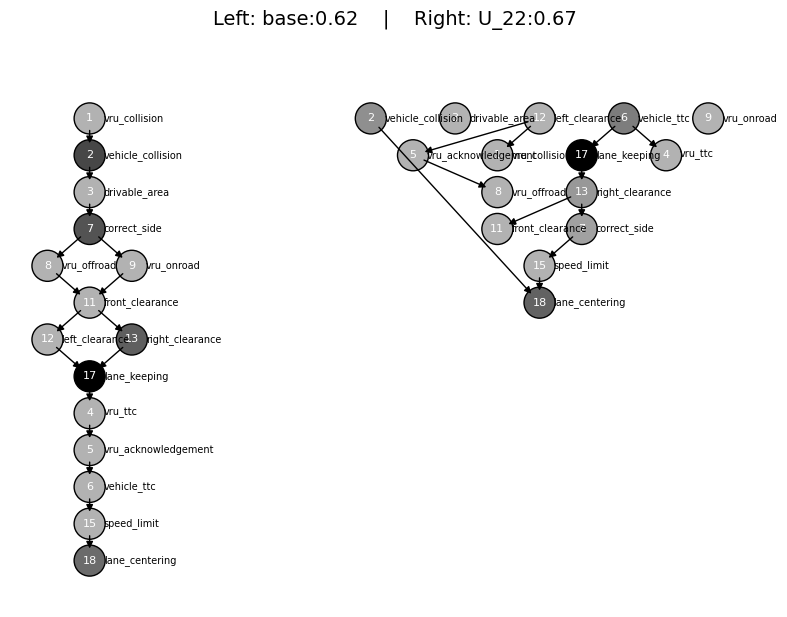

In [4]:


count = 0
for name, rb in rulebooks.items():
    if count < 2:
        count += 1
        continue
    if not nx.utils.graphs_equal(rb.in_place_priority_graph, rulebook.in_place_priority_graph):
        current_scenario = scenario_to_samples[name]

        correct, equal, incomparable, total, accuracy, weighted_accuracy, reasons = evaluate_rulebook_with_cache(rb, current_scenario['X'], current_scenario['y'], current_scenario['votes'], cache_dict, trajectories_dict)
        # aggregate reasons to get node weights
        # drop None values
        reasons = [r for r in reasons if r is not None]
        unique, counts = np.unique(reasons, return_counts=True)
        
        weights = dict(zip(unique, counts))

        
        correct, equal, incomparable, total, accuracy_base, weighted_accuracy, reasons = evaluate_rulebook_with_cache(rulebook, current_scenario['X'], current_scenario['y'], current_scenario['votes'], cache_dict, trajectories_dict)
        reasons = [r for r in reasons if r is not None]
        unique, counts = np.unique(reasons, return_counts=True)
        weights_base = dict(zip(unique, counts))

        plot_two_rulebooks_side_by_side(
            rulebook.in_place_priority_graph,
            rb.in_place_priority_graph,
            scenario_name=f"base:{accuracy_base:.2f}",
            scenario_name2=f"{name}:{accuracy:.2f}",
            rule_id_to_name=rule_id_to_name,
            figsize=(8,6),
            weights1=weights_base,
            weights2=weights
        )
        break
        

In [7]:
correct, equal, incomparable, total, accuracy_base, weighted_accuracy, reasons = evaluate_rulebook_with_cache(rulebook, X, y, votes, cache_dict, trajectories_dict)

In [10]:
traj_reasons= list(zip(reasons, X, y))

In [ ]:
count = 0
for r in traj_reasons:
    if count < 10:
        count += 1
        continue
    anim = compare_realizations_gif(trajectories_dict[r[1]], tr)
    

In [ ]:
print(traj_reasons)

[(3, ('S_2-a', 'S_2-c'), <Relation.LARGER: 1>), (18, ('U_24-d', 'U_24-g'), <Relation.LARGER: 1>), (7, ('S_22-a', 'S_22-d'), <Relation.LARGER: 1>), (7, ('U_3-a', 'U_3-b'), <Relation.LARGER: 1>), (4, ('U_7-a', 'U_7-c'), <Relation.LARGER: 1>), (2, ('U_16-a', 'U_16-e'), <Relation.LARGER: 1>), (8, ('U_35-c', 'U_35-d'), <Relation.SMALLER: 2>), (2, ('U_20-a', 'U_20-g'), <Relation.SMALLER: 2>), (3, ('S_24-b', 'S_24-c'), <Relation.LARGER: 1>), (8, ('U_61-d', 'U_61-e'), <Relation.SMALLER: 2>), (3, ('U_55-b', 'U_55-e'), <Relation.LARGER: 1>), (8, ('U_35-a', 'U_35-e'), <Relation.LARGER: 1>), (18, ('U_12-f', 'U_12-h'), <Relation.LARGER: 1>), (7, ('S_10-a', 'S_10-e'), <Relation.LARGER: 1>), (13, ('U_46-a', 'U_46-b'), <Relation.SMALLER: 2>), (None, ('U_10-a', 'U_10-i'), <Relation.SMALLER: 2>), (13, ('U_3-d', 'U_3-e'), <Relation.SMALLER: 2>), (2, ('U_14-e', 'U_14-i'), <Relation.LARGER: 1>), (3, ('U_53-a', 'U_53-f'), <Relation.LARGER: 1>), (7, ('U_21-a', 'U_21-b'), <Relation.SMALLER: 2>), (7, ('S_18-b'

In [21]:
shuffled_rulebook = shuffle_rulebook(rulebook, seed=43)

best_rb, score = simulated_annealing(shuffled_rulebook, X, y, votes, cache_dict, trajectories_dict)
print("Best score after simulated annealing:", score)

Initial Score: 1254


Best score after simulated annealing: 1294


In [6]:
best_correct, best_equal, best_incomparable, best_total, best_accuracy, best_weighted_accuracy, best_reasons = evaluate_rulebook_with_cache(best_rb, X, y, votes, cache_dict, trajectories_dict)
base_correct, base_equal, base_incomparable, base_total, base_accuracy, base_weighted_accuracy, base_reasons = evaluate_rulebook_with_cache(rulebook, X, y, votes, cache_dict, trajectories_dict)
# aggregate reasons to get node weights
# drop None values
reasons = [r for r in best_reasons if r is not None]
unique, counts = np.unique(reasons, return_counts=True)
weights = dict(zip(unique, counts))
reasons = [r for r in base_reasons if r is not None]
unique, counts = np.unique(reasons, return_counts=True)
weights_base = dict(zip(unique, counts))


NameError: name 'best_rb' is not defined

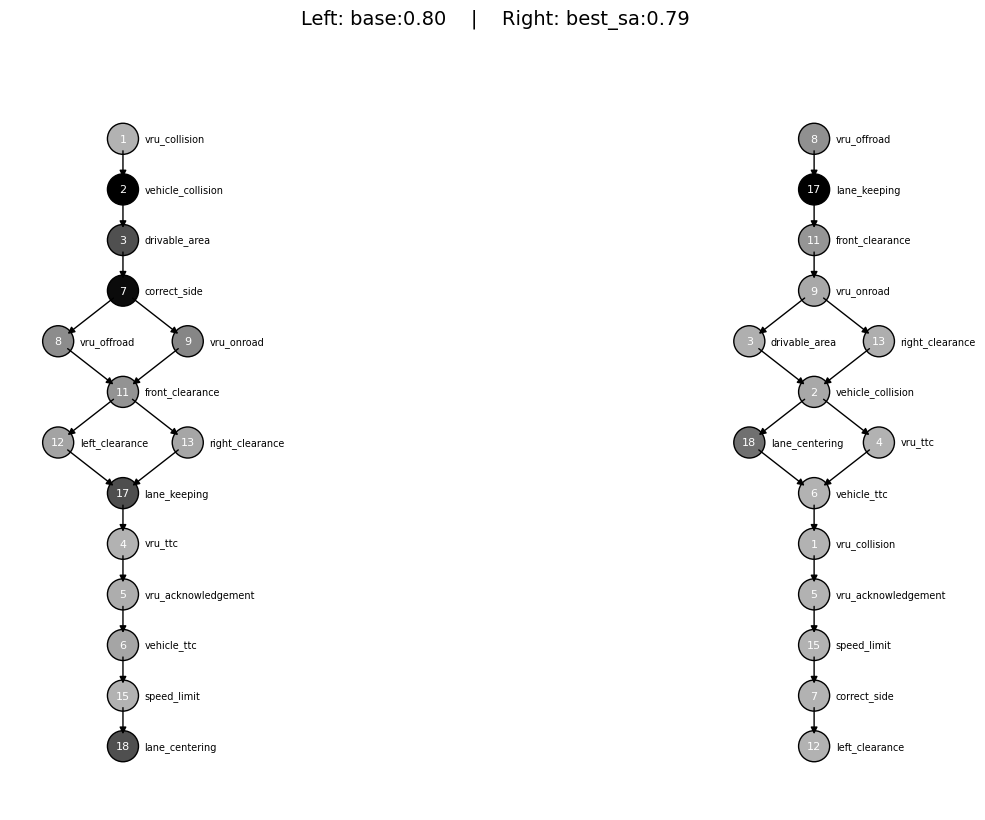

In [24]:
plot_two_rulebooks_side_by_side(rulebook.in_place_priority_graph, best_rb.in_place_priority_graph, rule_id_to_name=rule_id_to_name, weights1=weights_base, weights2=weights, scenario_name=f"base:{base_accuracy:.2f}", scenario_name2=f"best_sa:{best_accuracy:.2f}", figsize=(10,8))